In [1]:
import time
import os
import cv2
import numpy as np
from imutils import paths
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# Key parameters
IMAGE_DIMS = (224, 224)  # EfficientNet-B0 expects 224x224 images
dataset_dir = "C:/Users/Souma Chakraborty/OneDrive/Desktop/ML_RESEARCH/Fruit And Vegetable Diseases Dataset"
ALLOWED_CLASSES = {"Potato__Healthy", "Potato__Rotten"}

class FruitDataset(Dataset):
    def __init__(self, imagePaths, labels, transform=None):
        self.imagePaths = imagePaths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.imagePaths)

    def __getitem__(self, idx):
        imagePath = self.imagePaths[idx]
        image = cv2.imread(imagePath)
        if image is None:
            raise ValueError(f"Failed to load image: {imagePath}")
        image = cv2.resize(image, IMAGE_DIMS)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = image.astype("float32") / 255.0
        if self.transform:
            image = self.transform(image)
        else:
            image = torch.from_numpy(image.transpose(2, 0, 1))
        label = self.labels[idx]
        return image, label

def load_data():
    data = []
    labels = []
    imagePaths = list(paths.list_images(dataset_dir))
    print(f"Found {len(imagePaths)} images in total.")
    for imagePath in imagePaths:
        label = imagePath.split(os.path.sep)[-2]
        if label not in ALLOWED_CLASSES:
            continue
        if cv2.imread(imagePath) is None:
            print(f"Failed to load image: {imagePath}")
            continue
        data.append(imagePath)
        labels.append(label)
    print(f"\nProcessed {len(data)} images")
    print(f"Unique labels found: {set(labels)}")
    if len(data) == 0:
        raise ValueError("No images were processed. Check your dataset directory and paths.")
    le = LabelEncoder()
    encoded_labels = le.fit_transform(labels)
    (trainPaths, testPaths, trainLabels, testLabels) = train_test_split(
        data, encoded_labels, test_size=0.20, random_state=42)
    return trainPaths, testPaths, trainLabels, testLabels, le

trainPaths, testPaths, trainLabels, testLabels, le = load_data()

# (Optional) Additional transform if needed
transform = transforms.Compose([
    transforms.ToTensor()  # Converts image from HWC [0,1] to CHW tensor [0,1]
])

trainDataset = FruitDataset(trainPaths, trainLabels, transform=None)
testDataset = FruitDataset(testPaths, testLabels, transform=None)

BS = 32  # Batch size
trainLoader = DataLoader(trainDataset, batch_size=BS, shuffle=True, num_workers=0, drop_last=True)
testLoader = DataLoader(testDataset, batch_size=BS, shuffle=False, num_workers=0, drop_last=True)


Found 14770 images in total.

Processed 1198 images
Unique labels found: {'Potato__Rotten', 'Potato__Healthy'}


In [2]:
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import torchvision.models as models
import time

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained EfficientNet-B0
efficientnet = models.efficientnet_b0(pretrained=True)
# Replace the classifier (EfficientNet-B0 uses a classifier which is a Sequential with Dropout and Linear)
num_features = efficientnet.classifier[1].in_features
efficientnet.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(num_features, len(le.classes_))
)
efficientnet = efficientnet.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(efficientnet.parameters(), lr=1e-4)

print(efficientnet)
print(f"Training EfficientNet-B0 on device: {device}")

# Initialize training history lists
EPOCHS = 5  # Number of epochs to train
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

print("[INFO] Training EfficientNet-B0 model...")
for epoch in range(EPOCHS):
    efficientnet.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0
    for images, labels in tqdm(trainLoader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = efficientnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels.data)
        total += images.size(0)
    epoch_loss = running_loss / total
    epoch_acc = running_corrects.double() / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc.item())
    
    efficientnet.eval()
    val_running_loss = 0.0
    val_running_corrects = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in testLoader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = efficientnet(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_running_corrects += torch.sum(preds == labels.data)
            val_total += images.size(0)
    val_loss = val_running_loss / val_total
    val_acc = val_running_corrects.double() / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc.item())
    print(f"Epoch {epoch+1}/{EPOCHS}: Train loss {epoch_loss:.4f}, Train acc {epoch_acc:.4f}, Val loss {val_loss:.4f}, Val acc {val_acc:.4f}")

# Define evaluation function
def evaluate(model, dataloader, device_eval):
    model.to(device_eval)
    model.eval()
    all_preds = []
    all_labels = []
    total_time = 0.0
    total_samples = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device_eval)
            start = time.time()
            outputs = model(images)
            end = time.time()
            total_time += (end - start)
            total_samples += images.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    avg_inference_time = (total_time / total_samples) * 1000  # ms per image
    return accuracy, avg_inference_time, all_preds, all_labels

fp32_accuracy, fp32_inference_time, all_preds, all_labels = evaluate(efficientnet, testLoader, device)
print(f"EfficientNet-B0 FP32 - Accuracy: {fp32_accuracy:.4f}, Inference Time: {fp32_inference_time:.2f} ms/image")


c:\Users\Souma Chakraborty\OneDrive\Desktop\ML_RESEARCH\resenv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Souma Chakraborty\OneDrive\Desktop\ML_RESEARCH\resenv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

Epoch 1/5: 100%|██████████| 29/29 [00:52<00:00,  1.79s/it]


Epoch 1/5: Train loss 0.4212, Train acc 0.8556, Val loss 0.2254, Val acc 0.9330


Epoch 2/5: 100%|██████████| 29/29 [00:52<00:00,  1.79s/it]


...

Epoch 3/5: Train loss 0.0659, Train acc 0.9860, Val loss 0.0952, Val acc 0.9598


Epoch 4/5: 100%|██████████| 29/29 [00:56<00:00,  1.96s/it]


Epoch 4/5: Train loss 0.0462, Train acc 0.9881, Val loss 0.0816, Val acc 0.9688


Epoch 5/5: 100%|██████████| 29/29 [00:54<00:00,  1.90s/it]


Epoch 5/5: Train loss 0.0414, Train acc 0.9903, Val loss 0.0845, Val acc 0.9643
EfficientNet-B0 FP32 - Accuracy: 0.9643, Inference Time: 14.53 ms/image


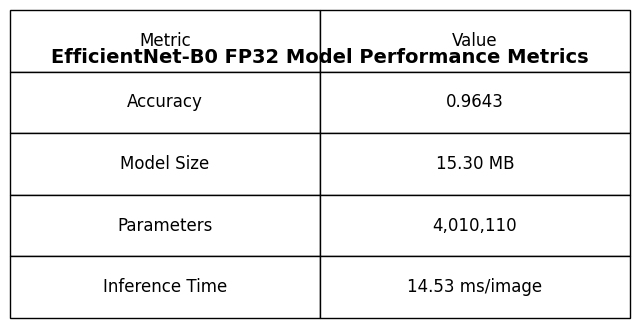

EfficientNet-B0 FP32 Model Classification Report:
              precision    recall  f1-score   support

     healthy       0.95      0.98      0.97       115
      rotten       0.98      0.94      0.96       109

    accuracy                           0.96       224
   macro avg       0.97      0.96      0.96       224
weighted avg       0.96      0.96      0.96       224



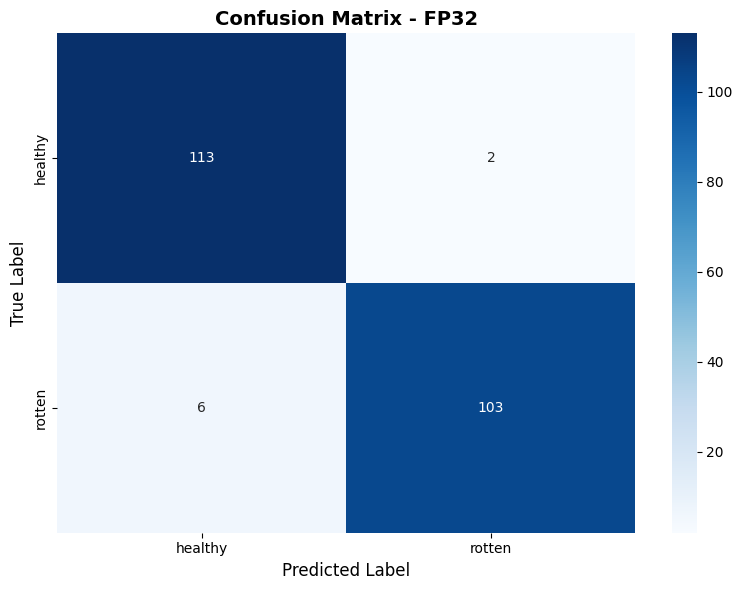

EfficientNet-B0 FP32 Model Confusion Matrix Accuracy: 0.9643
[INFO] Generating EfficientNet-B0 FP32 training history plot...


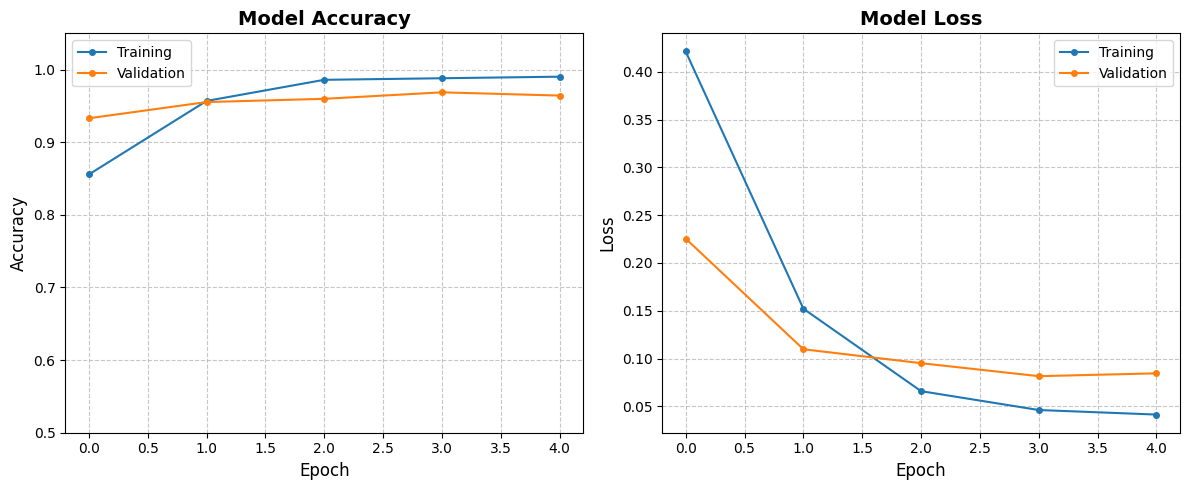

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Performance Metrics Table
def create_model_performance_metrics_fp32(model, test_accuracy, inference_time):
    total_params = sum(p.numel() for p in model.parameters())
    model_size_mb = total_params * 4 / (1024 * 1024)  # assuming 4 bytes per parameter
    metrics = {
        'Metric': ['Accuracy', 'Model Size', 'Parameters', 'Inference Time'],
        'Value': [f'{test_accuracy:.4f}', f'{model_size_mb:.2f} MB', f'{total_params:,}', f'{inference_time:.2f} ms/image']
    }
    metrics_df = pd.DataFrame(metrics)
    plt.figure(figsize=(8, 4))
    plt.axis('tight')
    plt.axis('off')
    table = plt.table(cellText=metrics_df.values,
                      colLabels=metrics_df.columns,
                      cellLoc='center',
                      loc='center',
                      bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 1.5)
    plt.title('EfficientNet-B0 FP32 Model Performance Metrics', fontsize=14, fontweight='bold', y=0.8)
    plt.show()
    return metrics_df

metrics_df_fp32 = create_model_performance_metrics_fp32(efficientnet, fp32_accuracy, fp32_inference_time)

# Simplify class names for display
simple_class_names = [name.replace("Potato__Healthy", "healthy")
                      .replace("Potato__Rotten", "rotten")
                      for name in le.classes_]

report_fp32 = classification_report(all_labels, all_preds, target_names=simple_class_names)
print("EfficientNet-B0 FP32 Model Classification Report:")
print(report_fp32)

def plot_confusion_matrix_fp32(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - FP32', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.show()
    accuracy = np.trace(cm) / np.sum(cm)
    return accuracy

cm_accuracy_fp32 = plot_confusion_matrix_fp32(all_labels, all_preds, simple_class_names)
print(f"EfficientNet-B0 FP32 Model Confusion Matrix Accuracy: {cm_accuracy_fp32:.4f}")

# Training History Graphs
def plot_training_history(train_losses, val_losses, train_acc, val_acc):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_acc, marker='o', linestyle='-', markersize=4, label='Training')
    plt.plot(val_acc, marker='o', linestyle='-', markersize=4, label='Validation')
    plt.title('Model Accuracy', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=10)
    plt.ylim([0.5, 1.05])
    
    plt.subplot(1, 2, 2)
    plt.plot(train_losses, marker='o', linestyle='-', markersize=4, label='Training')
    plt.plot(val_losses, marker='o', linestyle='-', markersize=4, label='Validation')
    plt.title('Model Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()

print("[INFO] Generating EfficientNet-B0 FP32 training history plot...")
plot_training_history(train_losses, val_losses, train_accuracies, val_accuracies)
